# Upper Confidence Bound (UCB)

## Importing the libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [6]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')
N, d = dataset.shape   # N = rounds, d = number of ads

## Implementing UCB

In [7]:
# import math
#
# N = 10000
# d = 10
# ads_selected = []
# numbers_of_selections = [0] * d
# sums_of_rewards = [0] * d
# total_reward = 0
#
# for n in range(0, N):
#     ad = 0
#     max_upper_bound = 0
#     for i in range(0, d):
#         if numbers_of_selections[i] == 0:        # ✅ select unplayed ads first
#             upper_bound = 1e400
#         else:
#             average_reward = sums_of_rewards[i] / numbers_of_selections[i]  # ✅ [i] added
#             delta_i = math.sqrt((3/2) * math.log(n + 1) / numbers_of_selections[i])
#             upper_bound = average_reward + delta_i
#         if upper_bound > max_upper_bound:        # ✅ fixed indentation
#             max_upper_bound = upper_bound
#             ad = i
#

# ── UCB Algorithm ─────────────────────────────────────────────────
import math
ads_selected        = []
numbers_of_selections = np.zeros(d, dtype=int)
sums_of_rewards       = np.zeros(d, dtype=float)
total_reward          = 0

for n in range(N):
    # Compute upper bound for each ad
    upper_bounds = []
    for i in range(d):
        if numbers_of_selections[i] == 0:
            ub = float('inf')                          # unplayed → always explore first
        else:
            avg     = sums_of_rewards[i] / numbers_of_selections[i]
            delta_i = math.sqrt((3/2) * math.log(n + 1) / numbers_of_selections[i])
            ub      = avg + delta_i
        upper_bounds.append(ub)

    # Select ad with highest upper bound
    ad = int(np.argmax(upper_bounds))
    ads_selected.append(ad)

    # Observe reward and update
    reward = dataset.values[n, ad]
    numbers_of_selections[ad] += 1
    sums_of_rewards[ad]       += reward
    total_reward               += reward


print(f"Total Reward      : {total_reward}")
print(f"Best Ad (0-indexed): {np.argmax(numbers_of_selections)}")
print(f"\nSelections per ad:")
for i, count in enumerate(numbers_of_selections):
    print(f"  Ad {i+1}: {count:>5} times  |  Avg reward: {sums_of_rewards[i]/count:.4f}")

Total Reward      : 2178
Best Ad (0-indexed): 4

Selections per ad:
  Ad 1:   705 times  |  Avg reward: 0.1702
  Ad 2:   387 times  |  Avg reward: 0.1214
  Ad 3:   186 times  |  Avg reward: 0.0376
  Ad 4:   345 times  |  Avg reward: 0.1101
  Ad 5:  6323 times  |  Avg reward: 0.2649
  Ad 6:   150 times  |  Avg reward: 0.0067
  Ad 7:   292 times  |  Avg reward: 0.0925
  Ad 8:  1170 times  |  Avg reward: 0.2017
  Ad 9:   256 times  |  Avg reward: 0.0781
  Ad 10:   186 times  |  Avg reward: 0.0376


## Visualising the results

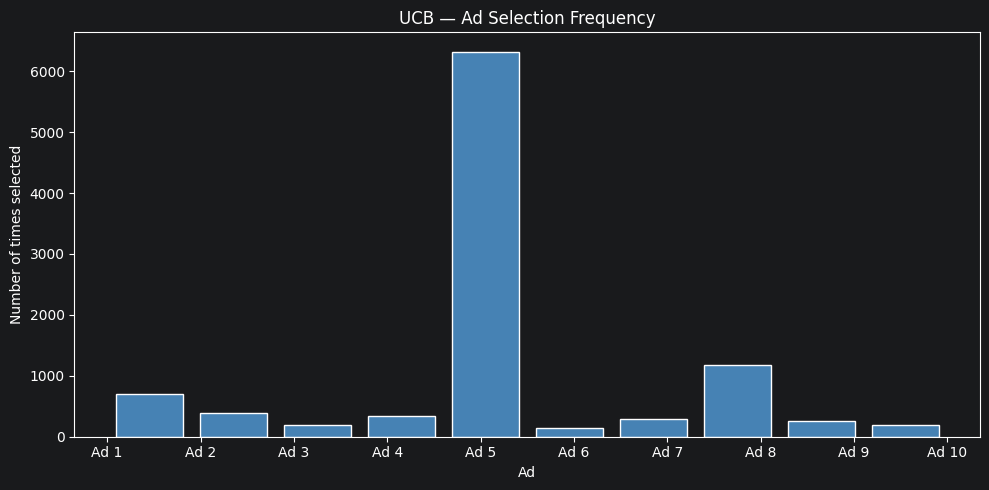

In [8]:
# plt.hist(ads_selected)
# plt.title('Histogram of ads selections')
# plt.xlabel('Ads')
# plt.ylabel('Number of times each ad was selected')
# plt.show()
#

plt.figure(figsize=(10, 5))
plt.hist(ads_selected, bins=d, rwidth=0.8, color='steelblue', edgecolor='white')
plt.title('UCB — Ad Selection Frequency')
plt.xlabel('Ad')
plt.ylabel('Number of times selected')
plt.xticks(range(d), [f'Ad {i+1}' for i in range(d)])
plt.tight_layout()
plt.savefig('ucb_selections.png', dpi=150)
plt.show()